In [1]:
import pandas as pd
import numpy as np

In [2]:
from pathlib import Path
BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / "data" / "processed"
REPORT_DIR=BASE_DIR/"reports"/"D6"

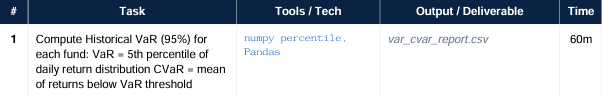

In [3]:
nav_df = pd.read_csv(PROCESSED_DIR/"nav_history_clean.csv")

In [4]:
nav_df.head()

,date,amfi_code,nav
0,2022-01-03,100016.0,520.4608
1,2022-01-04,100016.0,515.0971
2,2022-01-05,100016.0,521.7239
3,2022-01-06,100016.0,515.7880
4,2022-01-07,100016.0,515.1639


In [5]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

In [6]:
nav_df["daily_return"] = (nav_df.groupby("amfi_code")["nav"].pct_change())

In [7]:
returns_df = nav_df.dropna(subset=["daily_return"])

In [8]:
results = []
for fund, group in returns_df.groupby("amfi_code"):
    returns = group["daily_return"].values
    var_95 = np.percentile(returns, 5)
    cvar_95 = returns[returns <= var_95].mean()
    results.append({"amfi_code": fund,"VaR_95": round(var_95, 6),"CVaR_95": round(cvar_95, 6)})

In [9]:
var_cvar_report = pd.DataFrame(results)

In [10]:
var_cvar_report.to_csv(REPORT_DIR/"var_cvar_report.csv")
print(var_cvar_report.head())

   amfi_code    VaR_95   CVaR_95
0   100016.0 -0.012884 -0.016768
1   100025.0 -0.003338 -0.004581
2   100033.0 -0.016902 -0.021850
3   101206.0 -0.012173 -0.016075
4   101207.0 -0.023915 -0.030289


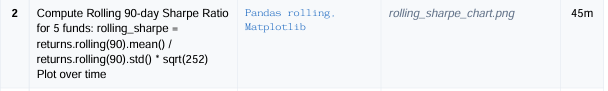

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns 

In [12]:
nav_df

,date,amfi_code,nav,daily_return
0,2022-01-03,100016.0,520.4608,NaN
1,2022-01-04,100016.0,515.0971,-0.010306
2,2022-01-05,100016.0,521.7239,0.012865
3,2022-01-06,100016.0,515.7880,-0.011377
4,2022-01-07,100016.0,515.1639,-0.001210
...,...,...,...,...
64315,2026-05-25,149324.0,292.4810,0.012106
64316,2026-05-26,149324.0,291.2707,-0.004138
64317,2026-05-27,149324.0,288.8007,-0.008480
64318,2026-05-28,149324.0,280.6873,-0.028093


In [13]:
top_5_funds = returns_df["amfi_code"].unique()[:5]

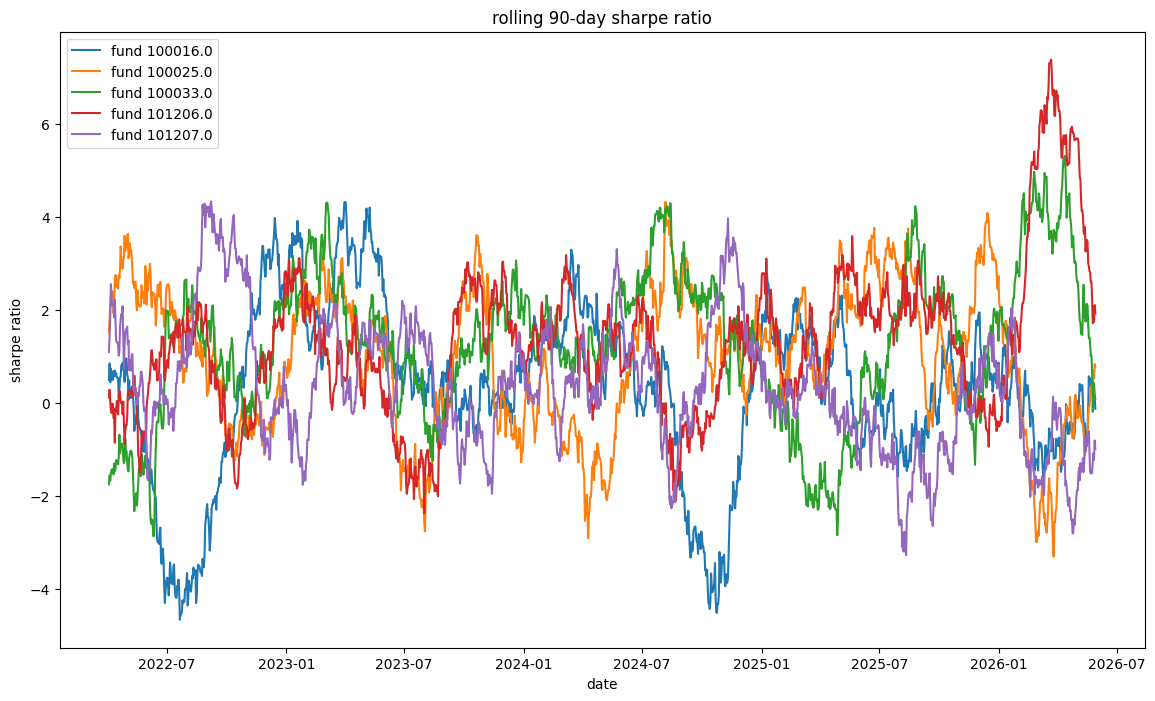

In [14]:
plt.figure(figsize=(14,8))
for fund in top_5_funds:
    fund_data = returns_df[returns_df["amfi_code"] == fund].copy()

    fund_data["rolling_sharpe"] = (fund_data["daily_return"].rolling(90).mean() /
                                   fund_data["daily_return"].rolling(90).std()) * np.sqrt(252)

    plt.plot(fund_data["date"], fund_data["rolling_sharpe"], label="fund " + str(fund))

plt.title("rolling 90-day sharpe ratio")
plt.xlabel("date")
plt.ylabel("sharpe ratio")
plt.legend()
plt.savefig(REPORT_DIR/"rolling_sharpe_chart.png")

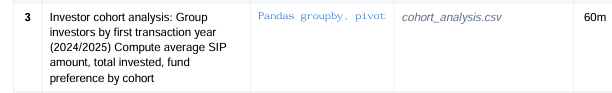

In [15]:
df = pd.read_csv(PROCESSED_DIR/"investor_transactions_clean.csv")

In [16]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

In [17]:
first_year = df.groupby("investor_id")["transaction_date"].min().dt.year

In [18]:
first_year

investor_id
INV000001    2024
INV000002    2024
INV000003    2024
INV000004    2024
INV000005    2024
             ... 
INV004996    2024
INV004997    2024
INV004998    2024
INV004999    2024
INV005000    2024
Name: transaction_date, Length: 5000, dtype: int32

In [19]:
df["cohort_year"] = df["investor_id"].map(first_year)

In [20]:
df.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status', 'cohort_year'],
      dtype='object')

In [21]:
cohort_stat = df.groupby("cohort_year").agg(avg_sip_amount=("amount_inr","mean"),total_invested=("amount_inr","sum")).reset_index()

In [22]:
cohort_stat

,cohort_year,avg_sip_amount,total_invested
0,2024,107422.541832,3491125187
1,2025,109158.577061,30455243


In [23]:
fund_pref = df.groupby(["cohort_year","amfi_code"]).size().reset_index(name="count")

In [24]:
fund_pref

,cohort_year,amfi_code,count
0,2024,100016,830
1,2024,100025,791
2,2024,100033,781
3,2024,101206,803
4,2024,101207,844
...,...,...,...
75,2025,148568,9
76,2025,148569,6
77,2025,149322,5
78,2025,149323,8


In [25]:
fund_pref.sort_values(["cohort_year","count"],ascending=[True,False],inplace=True)

In [26]:
fund_pref.duplicated().sum()

0

In [27]:
fund_pref = fund_pref[["cohort_year","amfi_code"]]

In [28]:
fund_pref.columns

Index(['cohort_year', 'amfi_code'], dtype='object')

In [29]:
fund_pref.columns = ["cohort_year","preferred_fund"]

In [30]:
fund_pref.columns

Index(['cohort_year', 'preferred_fund'], dtype='object')

In [32]:
cohort_analysis = pd.merge(cohort_stat,fund_pref,on="cohort_year")

In [33]:
cohort_analysis.head()

,cohort_year,avg_sip_amount,total_invested,preferred_fund
0,2024,107422.541832,3491125187,148568
1,2024,107422.541832,3491125187,125498
2,2024,107422.541832,3491125187,120504
3,2024,107422.541832,3491125187,119095
4,2024,107422.541832,3491125187,118636


In [34]:
cohort_analysis.to_csv(REPORT_DIR/"cohort_analysis.csv", index=False)

In [35]:
sip_df = df[df["transaction_type"].str.lower() == "sip"].copy()

In [36]:
sip_df = sip_df.sort_values(["investor_id", "transaction_date"])

In [37]:
sip_df["gap_days"] = sip_df.groupby("investor_id")["transaction_date"].diff().dt.days

In [38]:
sip_count = sip_df.groupby("investor_id").size()

In [39]:
valid_investors = sip_count[sip_count >= 6].index

In [40]:
sip_df = sip_df[sip_df["investor_id"].isin(valid_investors)]

In [41]:
result = sip_df.groupby("investor_id").agg(sip_transactions=("investor_id", "count"),avg_gap_days=("gap_days", "mean")).reset_index()

In [42]:
result["status"] = result["avg_gap_days"].apply(lambda x: "at-risk" if x > 35 else "active")

In [43]:
result

,investor_id,sip_transactions,avg_gap_days,status
0,INV000004,6,85.400000,at-risk
1,INV000008,6,70.400000,at-risk
2,INV000010,6,64.800000,at-risk
3,INV000011,7,40.166667,at-risk
4,INV000012,8,57.000000,at-risk
...,...,...,...,...
1357,INV004984,7,75.333333,at-risk
1358,INV004986,7,81.333333,at-risk
1359,INV004992,7,81.500000,at-risk
1360,INV004996,10,46.333333,at-risk


In [44]:
result.to_csv(REPORT_DIR/"sip_continuity.csv", index=False)

In [46]:
df = pd.read_csv(PROCESSED_DIR/"portfolio_holdings_clean.csv")

In [47]:
df.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [49]:
df["weight"] = df["weight_pct"] / 100

In [50]:
df

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date,weight
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31,0.1385
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31,0.1119
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31,0.0990
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31,0.0476
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31,0.1025
...,...,...,...,...,...,...,...,...,...
317,149324,DIVISLAB,Divi's Laboratories,Pharma,9.54,855.88,7453.05,2025-12-31,0.0954
318,149324,BHARTIARTL,Bharti Airtel Ltd,Telecom,1.79,969.71,924.41,2025-12-31,0.0179
319,149324,TCS,Tata Consultancy Services,IT,13.17,1637.69,1927.89,2025-12-31,0.1317
320,149324,INDUSINDBK,IndusInd Bank Ltd,Banking,7.63,1387.30,3208.86,2025-12-31,0.0763


In [51]:
sector_hhi = df.groupby("amfi_code")["weight"].apply(lambda x: np.sum(x * x)).reset_index()

In [52]:
sector_hhi.columns = ["amfi_code", "hhi"]

In [53]:
sector_hhi["portfolio_type"] = sector_hhi["hhi"].apply(lambda x: "concentrated" if x > 0.15 else "diversified")

In [54]:
sector_hhi.to_csv(REPORT_DIR/"sector_hhi.csv", index=False)

In [55]:
top_funds = sector_hhi.sort_values("hhi", ascending=False).head(10)

In [56]:
top_funds

,amfi_code,hhi,portfolio_type
11,119092,0.206448,concentrated
3,101207,0.200700,concentrated
18,119599,0.174751,concentrated
4,102885,0.174709,concentrated
7,118632,0.168298,concentrated
29,148568,0.167930,concentrated
21,120505,0.157570,concentrated
22,120506,0.153794,concentrated
27,125498,0.152414,concentrated
23,120841,0.149680,diversified


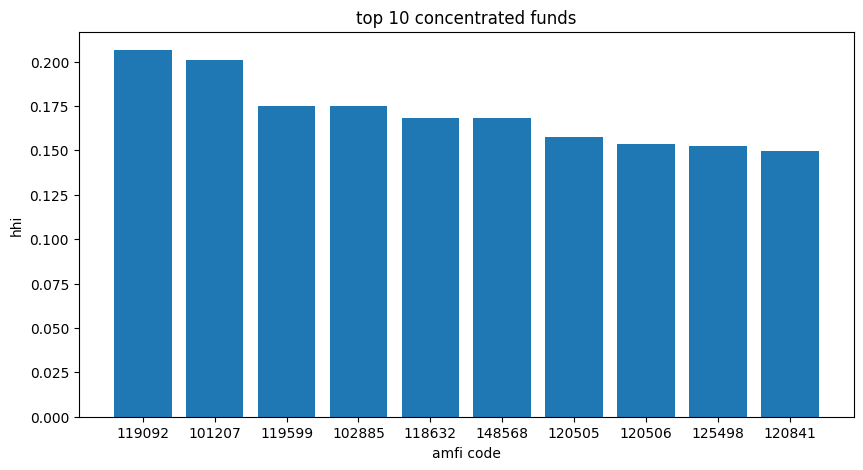

In [57]:
plt.figure(figsize=(10,5))
plt.bar(top_funds["amfi_code"].astype(str), top_funds["hhi"])
plt.title("top 10 concentrated funds")
plt.xlabel("amfi code")
plt.ylabel("hhi")
plt.savefig(REPORT_DIR/"sector_hhi_chart.png")

# Advanced Analytics Summary

## Some Main Things I Found

### 1. Funds with Highest Risk
After calculating VaR, I found that some funds have much bigger downside risk than others. These funds can lose more money when market conditions become bad. So investors should be little careful before investing in them.

### 2. CVaR Shows Actual Bad Cas
VaR only tells the minimum expected loss, but CVaR shows what can happen if things go really bad. Few funds had very high CVaR values which means losses can become much larger than expected in worst situations.

### 3. Sharpe Ratio Performance
By looking at 90-day rolling Sharpe Ratio, some funds were giving better return compared to the risk they were taking. These funds looked more stable and performed better for long period.

### 4. Investor Cohort Analysis
When I checked investor cohorts, I noticed that recent year investors invested more money compared to older cohorts. This can be because mutual funds are becoming more popular and people are getting more aware about investing.

### 5. Sector Exposure
Many funds had large holdings in Banking and Financial sectors. Because of this, performance of these sectors can affect overall fund returns a lot. If these sectors perform good then fund can also perform good, but opposite can also happen.

## Final Thoughts

From this analysis I understood that all funds are not same. Some funds give good returns but also carry more risk, while some are more balanced. VaR and CVaR helped in understanding risk side and Sharpe Ratio helped in checking performance. Cohort analysis was also interesting because it showed how investor behaviour is changing with time. Overall this analysis gave a better idea about fund performance and investor trends.